[0.0s] Fitting HMM on 1988-1997 (10 restarts)...


/Users/yushe/Desktop/UNI/FALL26/CSCD94/FlexibleEmissionHMM/.venv/lib/python3.10/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])


[1.6s] Fitting supervised models on 1988-1997...
[1.9s] Selecting regime strategies on development: 1998-2001...
[2.0s] Evaluating frozen co-rotation and baselines on test: 2002-2004...
[2.1s] Benchmark calculations complete.

Training: 1988-1997 | Development: 1998-2001 | Test: 2002-2004

Training moments and heuristic regime names:
    mean_r_%day  sd_r_%day  mean_sigma_%day    regime
0    -0.009042   1.084873         1.035769  sideways
1     0.076204   0.696509         0.670518      bull
2    -0.002781   2.050123         1.742504      bear

Development day counts:
 regime
bear         272
sideways     581
bull         151
dev_all     1004

Development selection Sharpes:
                 bear  sideways   bull  dev_all
buy_and_hold   1.109    -0.311 -0.044    0.204
ma_50_200      1.105     0.077 -0.044    0.356
vol_target_60  0.843    -0.431 -0.180   -0.039
tsmom_126      0.595     0.289 -0.313    0.327
mean_rev_z20   0.938    -0.287  0.940    0.264
logistic_up    0.942    -0.263 -0.5

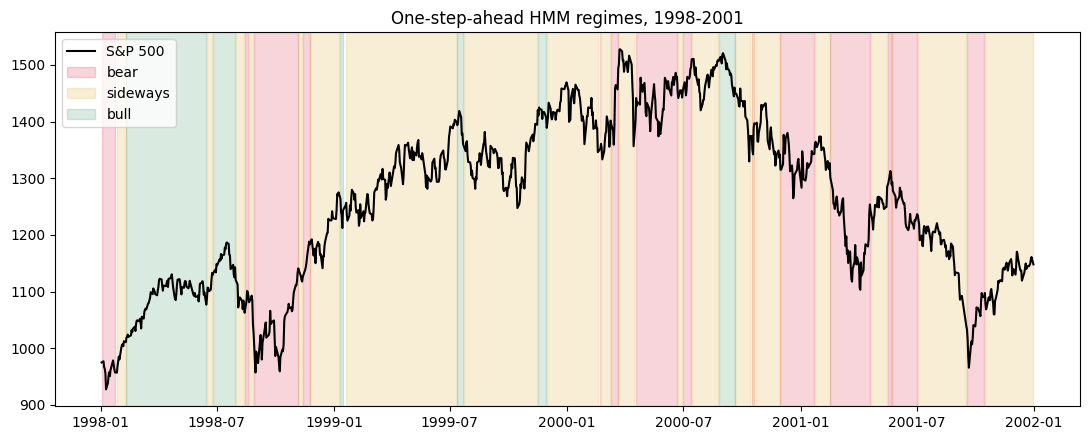

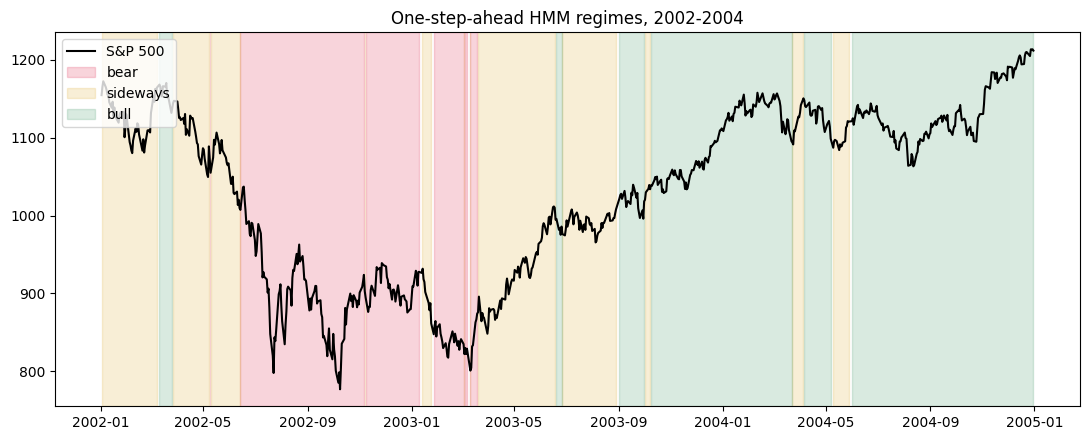

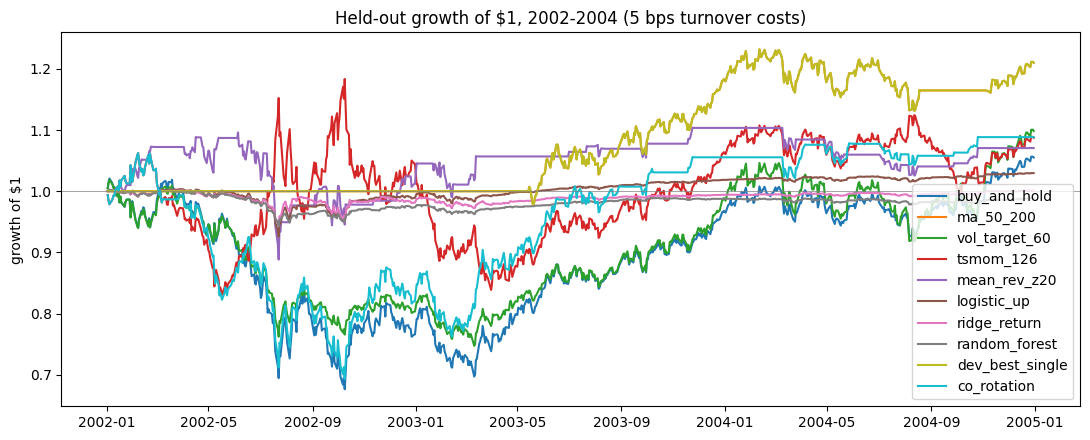

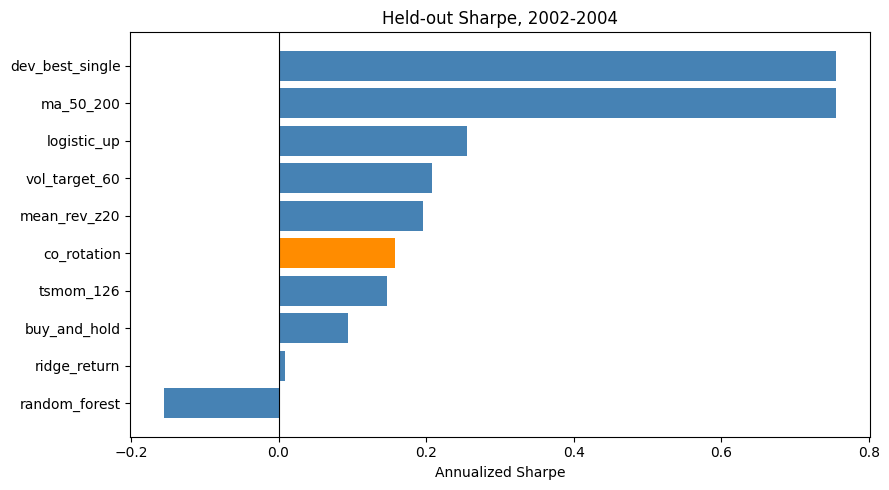

In [ ]:
"""Development-selected regime co-rotation and held-out S&P 500 benchmarks."""

import argparse
import logging
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(__file__).resolve().parents[2]
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(Path(__file__).resolve().parent))

from sp500_regime_algorithm_matrix import (  # noqa: E402
    COST_BPS,
    DATA_PATH,
    REGIMES,
    TRAIN_END,
    TRAIN_START,
    build_features,
    causal_regimes,
    fit_hmmlearn,
    fit_ml,
    name_regimes,
    sharpe_matrix,
    strategy_weights,
)
from model_evaluation.market_strategy import (  # noqa: E402
    compare_strategies,
    plot_equity_curves,
)

DEV_START, DEV_END = "1998-01-01", "2001-12-31"
TEST_START, TEST_END = "2002-01-01", "2004-12-31"
MIN_REGIME_DAYS = 20
"""Minimum development observations for selection; small samples remain noisy."""

FALLBACK_STRATEGY = "buy_and_hold"
"""Use a fixed passive fallback if a development regime cannot be scored."""


## Development selection and executable co-rotation


def split_returns(returns):
    """Split returns into complete, disjoint training, development, and test years.

    Args:
        returns: Daily returns with unique, increasing dates.

    Returns:
        A dictionary of training, development, and test return series.
    """
    if not returns.index.is_unique or not returns.index.is_monotonic_increasing:
        raise ValueError("Return dates must be unique and increasing")
    bounds = {
        "training": (TRAIN_START, TRAIN_END),
        "development": (DEV_START, DEV_END),
        "test": (TEST_START, TEST_END),
    }
    splits = {}
    previous_end = None
    for name, (start, end) in bounds.items():
        split = returns.loc[start:end]
        expected_years = list(range(pd.Timestamp(start).year, pd.Timestamp(end).year + 1))
        if split.empty or split.index.year.unique().tolist() != expected_years:
            raise ValueError(f"Missing requested years in {name}: {start} to {end}")
        if previous_end is not None and split.index[0] <= previous_end:
            raise ValueError("Training, development, and test dates must not overlap")
        splits[name] = split
        previous_end = split.index[-1]
    return splits


def select_rotation(development_table, counts):
    """Choose each regime's maximum finite development Sharpe without test input.

    Args:
        development_table: Strategies by regime, plus a ``dev_all`` column.
        counts: Number of development observations in each regime.

    Returns:
        Frozen regime-to-strategy map and the best whole-development strategy.
        Ties follow table row order; unscorable regimes use buy and hold.
    """
    if FALLBACK_STRATEGY not in development_table.index:
        raise ValueError("Development candidates must include the fallback")
    rotation = {}
    for regime in REGIMES:
        scores = development_table[regime].replace([np.inf, -np.inf], np.nan).dropna()
        rotation[regime] = (
            scores.idxmax()
            if counts[regime] >= MIN_REGIME_DAYS and not scores.empty
            else FALLBACK_STRATEGY
        )
    overall = development_table["dev_all"].replace([np.inf, -np.inf], np.nan).dropna()
    best_single = overall.idxmax() if not overall.empty else FALLBACK_STRATEGY
    return rotation, best_single


def co_rotation_weights(weights, labels, rotation):
    """Select the mapped strategy's actual exposure before charging turnover.

    Args:
        weights: Causal candidate positions on identical dates.
        labels: Pre-trade regime labels, using only earlier observations.
        rotation: Fixed development-selected regime-to-strategy mapping.

    Returns:
        One combined position series, not a splice of candidate net returns.
    """
    if not weights.index.equals(labels.index):
        raise ValueError("Candidate positions and regimes must have identical dates")
    chosen = labels.map(rotation)
    if chosen.isna().any() or not chosen.isin(weights.columns).all():
        raise ValueError("Every regime must map to an available strategy")
    positions = pd.Series(0.0, index=weights.index, name="co_rotation")
    for name in chosen.unique():
        mask = chosen == name
        positions.loc[mask] = weights.loc[mask, name]
    if not np.isfinite(positions).all():
        raise ValueError("Selected positions must be finite")
    return positions


## Frozen-model benchmark


def run_benchmark(prices, progress=False):
    """Fit on training, select on development, and evaluate once on test.

    Args:
        prices: Existing SPX closes including pre-training rolling history.
        progress: Print flushed stage messages when true.

    Returns:
        Development selection evidence, test positions and PnL, regime Sharpes,
        and whole-test performance summaries. All test portfolios start in cash.
    """
    started = perf_counter()

    def report(message):
        if progress:
            print(f"[{perf_counter() - started:.1f}s] {message}", flush=True)

    prices = prices.loc[:TEST_END]
    returns, emissions, ml_features = build_features(prices)
    splits = split_returns(returns)
    report("Fitting HMM on 1988-1997 (10 restarts)...")
    model = fit_hmmlearn(emissions.loc[TRAIN_START:TRAIN_END].to_numpy())
    names, moments = name_regimes(model)
    report("Fitting supervised models on 1988-1997...")
    fitted_ml = fit_ml(ml_features, returns)

    # Selection receives only development returns, positions, and causal labels.
    development = splits["development"]
    report("Selecting regime strategies on development: 1998-2001...")
    dev_labels, _ = causal_regimes(model, emissions, development.index, names)
    dev_weights = strategy_weights(prices, development.index, fitted_ml)
    dev_table, dev_counts, _ = sharpe_matrix(development, dev_weights, dev_labels)
    dev_table = dev_table.rename(columns={"test_all": "dev_all"})
    dev_counts = dev_counts.rename(index={"test_all": "dev_all"})
    rotation, best_single = select_rotation(dev_table, dev_counts)

    # Continue filtering through development; neither models nor map are refitted.
    test = splits["test"]
    report("Evaluating frozen co-rotation and baselines on test: 2002-2004...")
    test_labels, _ = causal_regimes(model, emissions, test.index, names)
    test_weights = strategy_weights(prices, test.index, fitted_ml)
    test_weights["dev_best_single"] = test_weights[best_single]
    test_weights["co_rotation"] = co_rotation_weights(
        test_weights, test_labels, rotation,
    )
    # Charge costs once on each actual portfolio, including initial entry and
    # changes caused by switching strategies. Identical exposures cost nothing.
    test_table, test_counts, test_pnl = sharpe_matrix(test, test_weights, test_labels)
    summary = compare_strategies(
        {name: test_pnl[name] for name in test_pnl},
        {name: test_weights[name] for name in test_weights},
    )
    report("Benchmark calculations complete.")
    return {
        "prices": prices,
        "splits": splits,
        "moments": moments,
        "development_table": dev_table,
        "development_counts": dev_counts,
        "development_labels": dev_labels,
        "rotation": rotation,
        "best_single": best_single,
        "test_labels": test_labels,
        "test_weights": test_weights,
        "test_pnl": test_pnl,
        "test_table": test_table,
        "test_counts": test_counts,
        "summary": summary,
    }


def max_drawdown(pnl):
    """Return the worst peak-to-trough loss from the initial $1 peak.

    Args:
        pnl: Daily log PnL of one causal portfolio.

    Returns:
        Max drawdown as a negative fraction; losses from day one count
        against the starting $1, unlike the package's ``drawdown``.
    """
    equity = np.exp(pnl.astype(float).cumsum())
    return float((equity / np.maximum(1.0, equity.cummax()) - 1.0).min())


def plot_regime_shading(prices, labels, title):
    """Plot causal regime shading over prices, matching the matrix notebook."""
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(prices.loc[labels.index], color="black", label="S&P 500")
    shading = {"bear": "crimson", "sideways": "goldenrod", "bull": "seagreen"}
    for regime, color in shading.items():
        ax.fill_between(
            labels.index, 0, 1, where=(labels == regime).values,
            transform=ax.get_xaxis_transform(), color=color, alpha=0.18,
            label=regime,
        )
    ax.legend(loc="upper left")
    ax.set(title=title)
    fig.tight_layout()


def plot_benchmark(result):
    """Plot dev and test regimes, equity, and Sharpe for co-rotation and baselines."""
    plot_regime_shading(result["prices"], result["development_labels"],
                        "One-step-ahead HMM regimes, 1998-2001")
    plot_regime_shading(result["prices"], result["test_labels"],
                        "One-step-ahead HMM regimes, 2002-2004")
    plot_equity_curves(
        {name: result["test_pnl"][name] for name in result["test_pnl"]},
        title="Held-out growth of $1, 2002-2004 (5 bps turnover costs)",
    )
    summary = result["summary"].sort_values("sharpe")
    colors = ["darkorange" if name == "co_rotation" else "steelblue"
              for name in summary.index]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(summary.index, summary["sharpe"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set(title="Held-out Sharpe, 2002-2004", xlabel="Annualized Sharpe")
    fig.tight_layout()


def main(show=True):
    """Print development selection and final test results, then optionally plot."""
    logging.getLogger("hmmlearn").setLevel(logging.ERROR)
    data = pd.read_csv(DATA_PATH, parse_dates=["YYYYMMDD"])
    prices = data.set_index("YYYYMMDD")["DlyPrcInd"].sort_index()
    result = run_benchmark(prices, progress=True)
    print("\nTraining: 1988-1997 | Development: 1998-2001 | Test: 2002-2004")
    print("\nTraining moments and heuristic regime names:\n", result["moments"])
    print("\nDevelopment day counts:\n", result["development_counts"].to_string())
    print("\nDevelopment selection Sharpes:\n",
          result["development_table"].round(3).to_string())
    print("\nFrozen co-rotation map:", result["rotation"])
    print("Development-selected single strategy:", result["best_single"])
    print("Selection: maximum finite net Sharpe; ties use candidate order;")
    print(f"fewer than {MIN_REGIME_DAYS} regime days or no valid score -> buy_and_hold.")
    print("\nTest day counts:\n", result["test_counts"].to_string())
    print("\nFinal test Sharpe matrix:\n", result["test_table"].round(3).to_string())
    summary = result["summary"]
    # Display-only correction: peak includes the initial $1; selection untouched.
    summary["max_drawdown"] = [
        max_drawdown(result["test_pnl"][name]) for name in summary.index
    ]
    columns = ["sharpe", "max_drawdown", "ann_return", "ann_volatility", "exposure"]
    print("\nFinal test performance:\n", summary[columns].round(3).to_string())
    print(f"\nCosts: {COST_BPS:g} bps per unit of actual portfolio turnover.")
    print("max_drawdown: worst peak-to-trough loss from the initial $1 peak.")
    print("All test portfolios start from cash; rolling/filter history is retained.")
    print("Signals use t-1 closes; same-close fills are idealized. Approximate log")
    print("PnL; cash rate is zero; financing and borrow costs are omitted.")
    print("Development winners are selection results, not independent evidence.")
    print("Test results must not be used to retune this map or select new features.")
    if show:
        plot_benchmark(result)
        print("Calculations finished. Close all plot windows to exit.", flush=True)
        plt.show()
    return result


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--no-show", action="store_true", help="Run without plot windows")
    # ``parse_known_args`` tolerates ipykernel's injected ``-f``/``--f`` flag.
    args, _ = parser.parse_known_args()
    main(show=not args.no_show)